In [48]:
import torch

DEVICE = "mps"

device = torch.device(DEVICE)
print(f"Using device: {device}")

# Pre-computed channel-wise mean and std from the dataset (used for normalization)
MEAN = [0.8128, 0.73, 0.7164]
STD = [0.2113, 0.299, 0.3102]

# Labels matching the folder names in Dataset/
CLASS_NAMES = ["bad onion", "good onion"]

Using device: mps


In [49]:
import copy
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

# Images are already 256x256 (run resize_dataset.py first)
# Training: random crop for augmentation so the model sees different crops each epoch
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Validation/Test: deterministic center crop for consistent evaluation
val_transform = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Load all images from Dataset/ (subfolders = class labels)
full_dataset = ImageFolder(root="./Dataset")
labels = [label for _, label in full_dataset.samples]

# Stratified 70/15/15 split — keeps the same bad/good ratio in each split
train_idx, temp_idx = train_test_split(range(len(full_dataset)), test_size=0.3, stratify=labels, random_state=42)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

# Each subset gets its own copy of the dataset so transforms don't conflict
train_data = Subset(copy.deepcopy(full_dataset), train_idx)
train_data.dataset.transform = train_transform
val_data = Subset(copy.deepcopy(full_dataset), val_idx)
val_data.dataset.transform = val_transform
test_data = Subset(copy.deepcopy(full_dataset), test_idx)
test_data.dataset.transform = val_transform

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 39, Val: 8, Test: 9


In [50]:
# ---- Deeper CNN with BatchNorm + Dropout (built for small datasets) ----
# 4 conv blocks with increasing filters (32→64→128→256)
# BatchNorm stabilizes training, Dropout (50%) prevents overfitting
# Global Average Pooling at the end instead of flattening — massively reduces params

class OnionNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Block 1: 3 → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                # 224 → 112
        )

        # Block 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                # 112 → 56
        )

        # Block 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                # 56 → 28
        )

        # Block 4: 128 → 256 channels
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),        # 28 → 1x1 (global average pool)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                # kill 50% of neurons to prevent overfitting
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.view(x.size(0), -1)          # (B, 256, 1, 1) → (B, 256)
        return self.classifier(x)

model = OnionNet(num_classes=len(CLASS_NAMES)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

Model params: 389,890


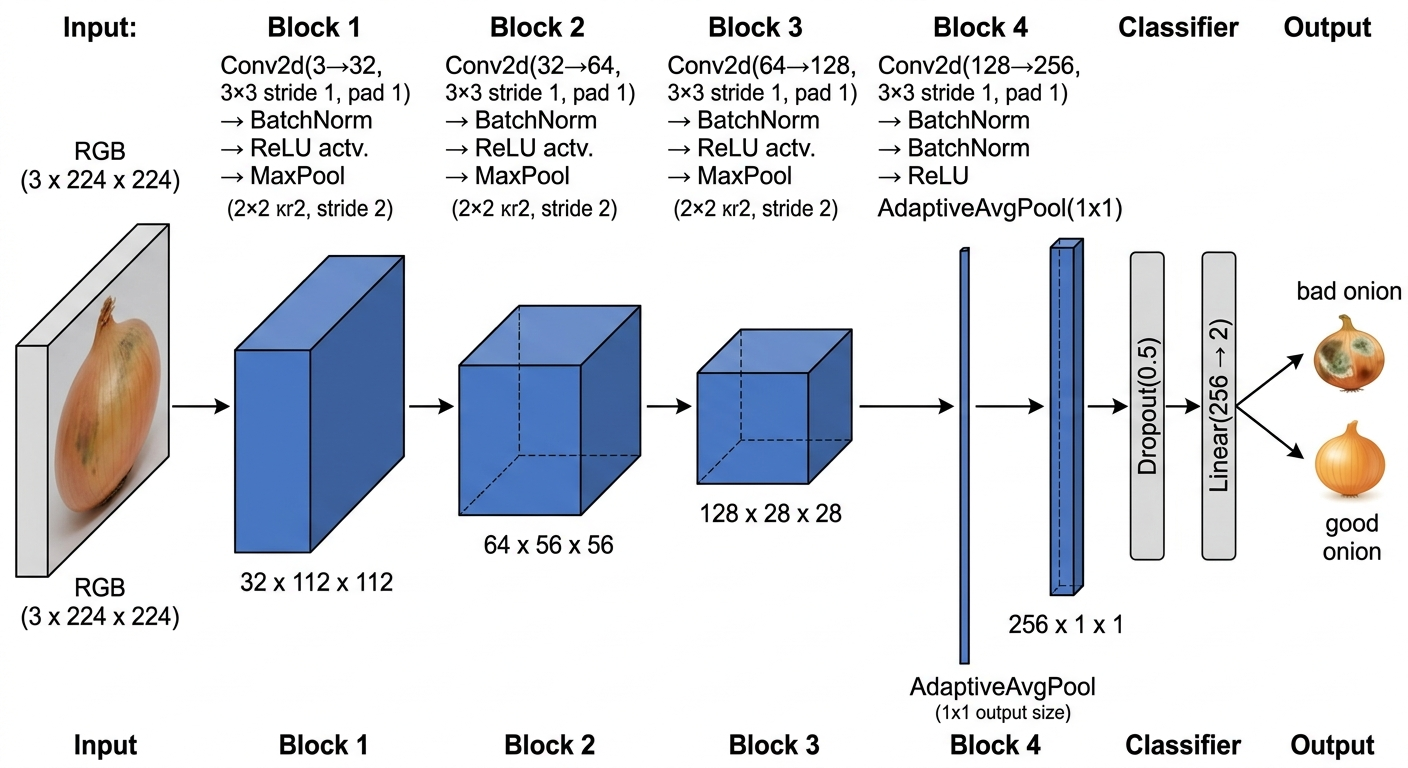

In [51]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="architecture.png"))

In [52]:
epochs = 50

# Track metrics for plotting
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # ---- Training phase ----
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()           # reset gradients
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                 # compute gradients
        optimizer.step()                # update weights
        train_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
    train_loss /= len(train_loader.dataset)
    train_acc = correct / total * 100

    # ---- Validation phase (no gradient updates) ----
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / total * 100

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} ({train_acc:.1f}%) | Val: {val_loss:.4f} ({val_acc:.1f}%)")

# Save trained weights for later inference / FastAPI server
torch.save(model.state_dict(), "model_weights.pth")
print("Model saved.")

Epoch 1/50 | Train: 0.7600 (56.4%) | Val: 0.6801 (75.0%)
Epoch 2/50 | Train: 0.5474 (69.2%) | Val: 0.6643 (62.5%)
Epoch 3/50 | Train: 0.4863 (84.6%) | Val: 0.6554 (50.0%)
Epoch 4/50 | Train: 0.3606 (74.4%) | Val: 0.6338 (50.0%)
Epoch 5/50 | Train: 0.3054 (92.3%) | Val: 0.6104 (50.0%)
Epoch 6/50 | Train: 0.2915 (89.7%) | Val: 0.5455 (50.0%)
Epoch 7/50 | Train: 0.2250 (97.4%) | Val: 0.4999 (62.5%)
Epoch 8/50 | Train: 0.3047 (87.2%) | Val: 0.5018 (62.5%)
Epoch 9/50 | Train: 0.1968 (94.9%) | Val: 0.5163 (50.0%)
Epoch 10/50 | Train: 0.2839 (92.3%) | Val: 0.4307 (75.0%)
Epoch 11/50 | Train: 0.1520 (100.0%) | Val: 0.3605 (87.5%)
Epoch 12/50 | Train: 0.2048 (92.3%) | Val: 0.4004 (75.0%)
Epoch 13/50 | Train: 0.1845 (97.4%) | Val: 0.5455 (62.5%)
Epoch 14/50 | Train: 0.2113 (94.9%) | Val: 0.6619 (75.0%)
Epoch 15/50 | Train: 0.2586 (89.7%) | Val: 0.5047 (87.5%)
Epoch 16/50 | Train: 0.2240 (92.3%) | Val: 0.2689 (87.5%)
Epoch 17/50 | Train: 0.2867 (84.6%) | Val: 0.1050 (100.0%)
Epoch 18/50 | Train: 

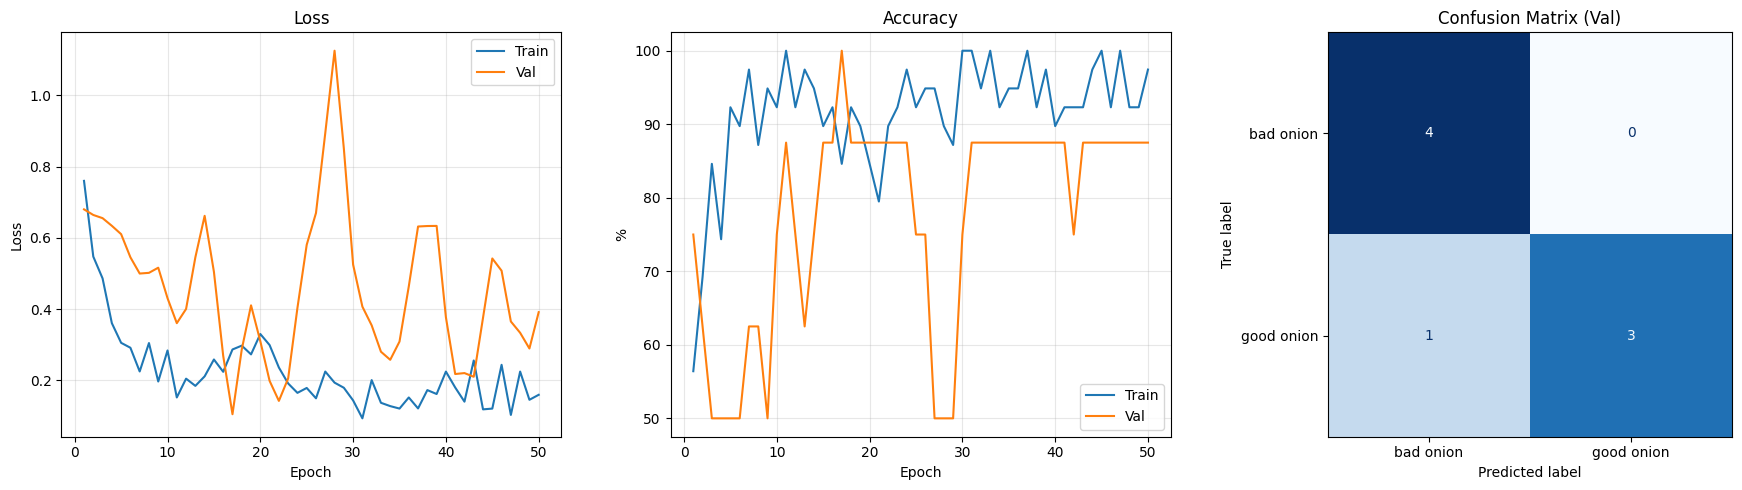

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epoch_range = range(1, len(train_losses) + 1)

# ---- 1. Loss curve ----
axes[0].plot(epoch_range, train_losses, label="Train")
axes[0].plot(epoch_range, val_losses, label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- 2. Accuracy curve ----
axes[1].plot(epoch_range, train_accs, label="Train")
axes[1].plot(epoch_range, val_accs, label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("%")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ---- 3. Confusion matrix on val set ----
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds = torch.argmax(model(images), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Confusion Matrix (Val)")

plt.tight_layout()
plt.savefig("training_graphs.png", dpi=200, bbox_inches="tight")
plt.show()

In [55]:
from PIL import Image

model.eval()
test_images = ["b1.png", "b2.jpg", "h1.png","h2.jpg","h3.jpeg"]
test_folder = "./Test_onion"

print(f"{'Image':<25} | {'Prediction':<15} | Confidence")
print("-" * 55)
for fname in test_images:
    img = Image.open(os.path.join(test_folder, fname)).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(device)  # add batch dim
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)  # logits → probabilities
        conf, idx = torch.max(probs, 1)
    print(f"{fname:<25} | {CLASS_NAMES[idx.item()]:<15} | {conf.item()*100:.1f}%")

Image                     | Prediction      | Confidence
-------------------------------------------------------
b1.png                    | bad onion       | 100.0%
b2.jpg                    | bad onion       | 100.0%
h1.png                    | good onion      | 98.5%
h2.jpg                    | good onion      | 99.6%
h3.jpeg                   | bad onion       | 82.1%
